# Machine Learning: Exercise session 07

In this exercise session we will focus on tree bagging and random forests for the practical parts.

The theoretical exercise is about the properties of bootstrap. We will derive the probability that a given observation is part of a bootstrap sample.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearnex import patch_sklearn
patch_sklearn(verbose=False)

## 0. Data import and Cleaning

Import the "Heart" dataset, containing demographic and medical informations about a list of patients. Drop `NA` values, convert the categorical variables into the desired pandas type: "category", and perform any other necessary data cleaning.

In [2]:
heart = pd.read_csv("Heart_ISL.csv",index_col=0)
heart = heart.dropna().reset_index(drop=True)
heart = heart.astype({'ChestPain':'category', 'Thal':'category', 'AHD':'category'})
print("Dataset shape:", heart.shape)
heart.head()

Dataset shape: (297, 14)


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [3]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Age        297 non-null    int64   
 1   Sex        297 non-null    int64   
 2   ChestPain  297 non-null    category
 3   RestBP     297 non-null    int64   
 4   Chol       297 non-null    int64   
 5   Fbs        297 non-null    int64   
 6   RestECG    297 non-null    int64   
 7   MaxHR      297 non-null    int64   
 8   ExAng      297 non-null    int64   
 9   Oldpeak    297 non-null    float64 
 10  Slope      297 non-null    int64   
 11  Ca         297 non-null    float64 
 12  Thal       297 non-null    category
 13  AHD        297 non-null    category
dtypes: category(3), float64(2), int64(9)
memory usage: 27.0 KB


The response variable that we will try to predict is "AHD", that indicates whether the patient has a heart disease.

Now split the data into the features `X` and the response `y`.

As, sadly, trees in sklearn do not handle categorical features directly, transform `X`'s categorical variables into "dummies". This can be achieved either with panda's `pd.get_dummies(<data>, drop_first=True)` or sklearn's `OneHotEncoder`. Make sure that you keep X in dataframe format, and keep feature/column names.

In [4]:
X = heart.drop("AHD", axis=1)
X = pd.get_dummies(X, drop_first=True)
y = heart["AHD"]

Split the data into train and test. Set random_state=40 and leave 20% of the data out for the test set.

In [5]:
# Split into train and test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)

## 1. Bagging and Random Forests

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

### 1.1 Forest of trees

Fit a random forest, with 200 trees and default values for the other hyper-parameters, to the heart dataset. Then plot three of the forest's trees.

Then do the same for a tree bagging model. What is the only hyper-parameter to change in the `RandomForestClassifier` to obtain a tree bagging model?

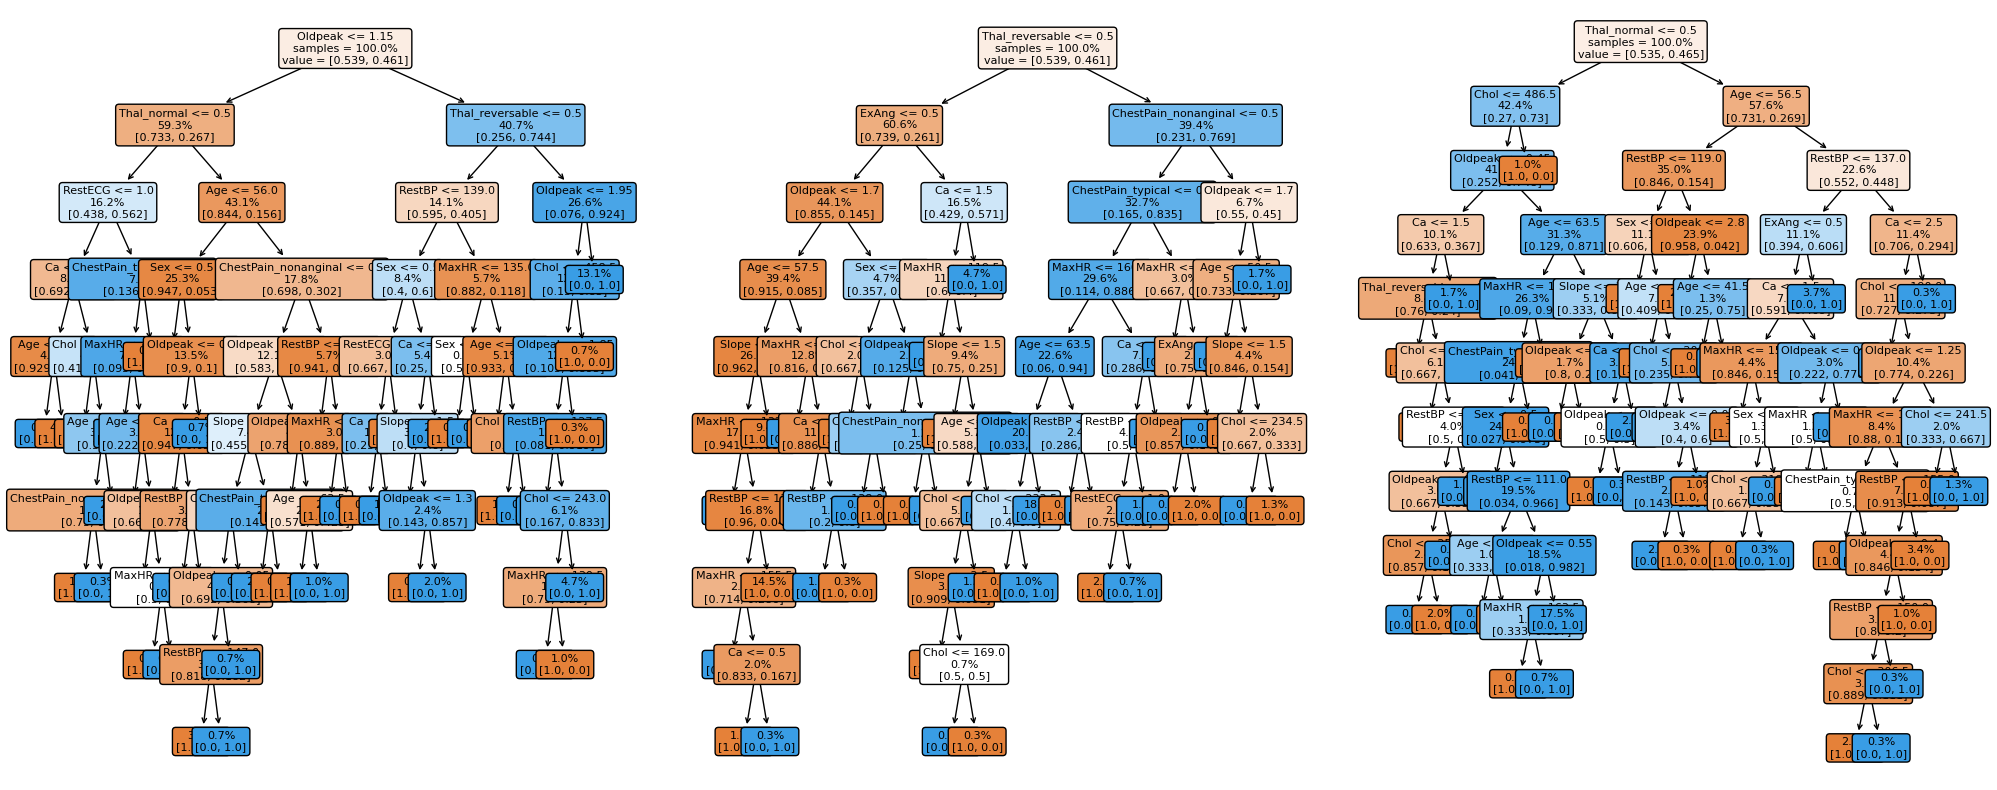

In [7]:
rfc = RandomForestClassifier(n_estimators=200, max_features="sqrt", random_state=1)
rfc.fit(X,y)

fig, axs = plt.subplots(1,3,figsize=(25,10))
for i, rf_tree in enumerate(rfc.estimators_[0:3]):
    plot_tree(rf_tree, feature_names=X_train.columns.tolist(), impurity=False, label="root",
              filled=True, proportion=True, rounded=True, fontsize=8, ax=axs[i])
plt.show()

In [8]:
np.sqrt(X_train.shape[1])

4.0

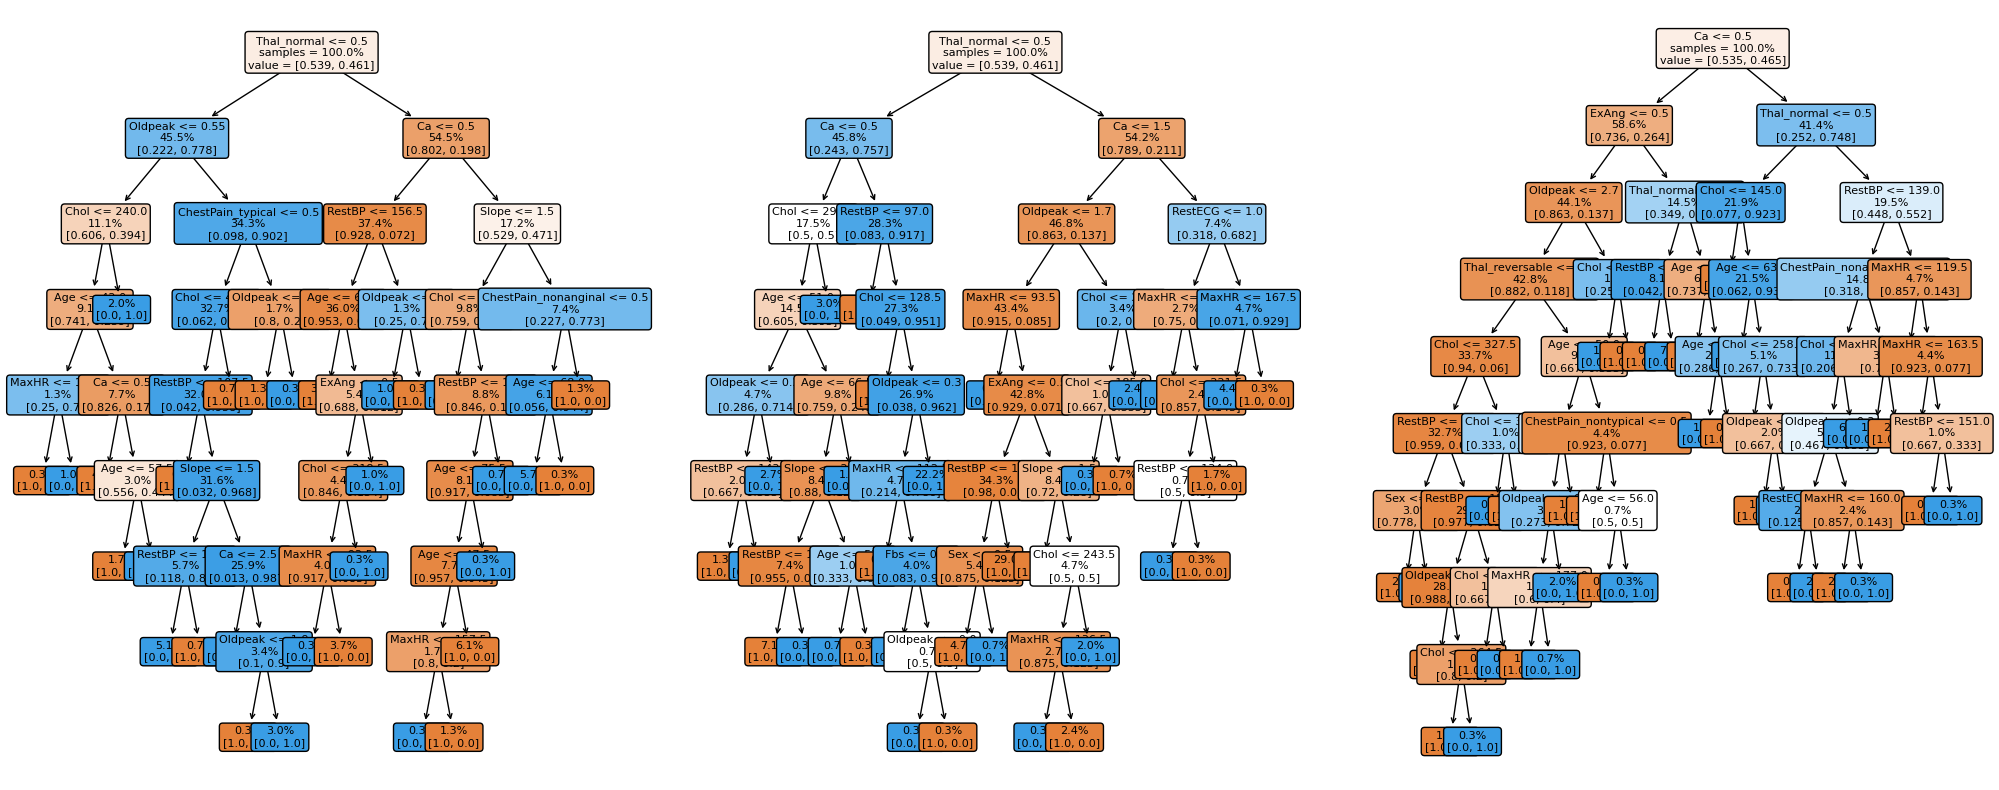

In [9]:
bagging = RandomForestClassifier(n_estimators=200, max_features=None, random_state=1)
bagging.fit(X,y)

fig, axs = plt.subplots(1,3,figsize=(25,10))
for i, rf_tree in enumerate(bagging.estimators_[0:3]):
    plot_tree(rf_tree, feature_names=X_train.columns.tolist(), impurity=False, label="root",
              filled=True, proportion=True, rounded=True, fontsize=8, ax=axs[i])
plt.show()

### 1.2 Tune the Forest

Now tune the hyper-parameters "max_features" and "min_samples_leaf" of the Random Forest classifier to minimize the expected generalization error.

You could use cross-validation. Is there another way to get the desired estimate other than with cross-validation? Use 2000 trees per forest or more.

_Hint:_ `sklearn.model_selection.ParameterGrid` and `<RF_instance>.set_params(...)` might be useful.

_Tip:_ In sklearn, you can set `n_jobs=-1` (or `n_jobs=-2`) in some models and in grid searches to use all (or all but one) of your computer's cores in parallel, which can reduce the running time depending on your computer. Be careful not to "nest" the parallelization.

In [10]:
# How do we access OOB score?
rfc = RandomForestClassifier(n_estimators=200, oob_score=True,
                             warm_start=False, random_state=1, n_jobs=-2)
rfc.fit(X_train, y_train)
rfc.oob_score_

C:\Users\pascheo\Anaconda3\lib\site-packages\daal4py\sklearn\ensemble\_forest.py:57: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warnings.warn(


0.8143459915611815

In [11]:
#Defaut "recommended" value for the hyper-parameter m
#(m=nb of variables randomly chosen to be considered at each split in each tree)
#We will search on a grid around it
default_max_features_param = np.sqrt(X_train.shape[1])
default_max_features_param

4.0

In [12]:
hyperparam_grid={"max_features":[2,3,4,5,6,7],
                 'min_samples_leaf':[1,3,5,7,9,11]}

In [13]:
from sklearn.model_selection import ParameterGrid

rfc = RandomForestClassifier(n_estimators=2000, oob_score=True,
                             warm_start=False, random_state=1, n_jobs=-2)
best_score=0.5

for g in ParameterGrid(hyperparam_grid):
    rfc.set_params(**g)
    #or rfc.set_params(min_samples_leaf=g['min_samples_leaf'], max_features=g['max_features'])
    
    rfc.fit(X_train,y_train)
    
    # save if best
    if rfc.oob_score_ > best_score:
        best_score = rfc.oob_score_
        best_params = g

print(f"OOB: {best_score:0.5f}")
print("Best parameters:", best_params)

OOB: 0.83544
Best parameters: {'max_features': 3, 'min_samples_leaf': 7}


_Remark:_ When comparing the Random Forest performance with other models, it is better to use cross-validation error estimates, so that the estimates are comparable between models.

### 2.3. Model Diagnostic

We now want to use different metrics to evaluate the model performance on the test set. To do so, consider the best random forest model according to cross-validation score. The first step is to predict the response classes on the test set.

In [14]:
rfc = RandomForestClassifier(n_estimators=2000, max_features=best_params['max_features'],
                             min_samples_leaf=best_params['min_samples_leaf'],
                             oob_score=True, warm_start=False, random_state=1, n_jobs=-2)
rfc.fit(X_train,y_train)

RandomForestClassifier(max_features=3, min_samples_leaf=7, n_estimators=2000,
                       n_jobs=-2, oob_score=True, random_state=1)

In [15]:
y_hat = rfc.predict(X_test)
y_prob = rfc.predict_proba(X_test)

On top of checking the test classification score, one can compute the confusion matrix using the `confusion_matrix()` function and plot it. You can use the `ConfusionMatrixDisplay` helper, or create the plot yourself. Comment the results.

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [17]:
rfc.oob_score_

0.8354430379746836

In [18]:
rfc.score(X_test, y_test)

0.8666666666666667

In [19]:
cm = confusion_matrix(y_test, y_hat)
cm

array([[27,  2],
       [ 6, 25]], dtype=int64)

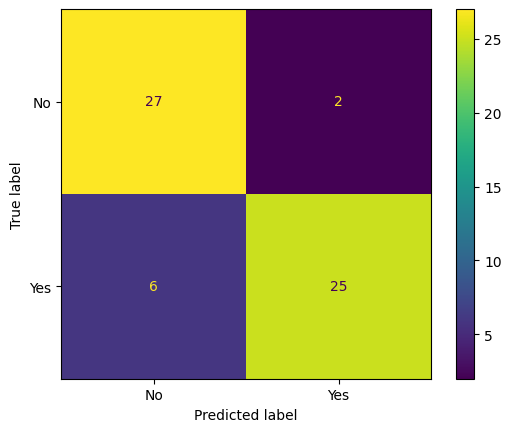

In [20]:
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc.classes_).plot()
plt.show()

Perform a classification report using the `classification_report()` function, and comment the results.

In [21]:
print(classification_report(y_test, y_hat, target_names=rfc.classes_))

              precision    recall  f1-score   support

          No       0.82      0.93      0.87        29
         Yes       0.93      0.81      0.86        31

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



precision = $TP/(TP+FP)$ = When the model is predicting this class, how often it is right

recall = $TP/(TP+FN)$ = How well the model is performing (accuracy) within each (true) class

F1 = harmonic mean of precision and recall = $\frac{2}{(1/precision)+(1/recall)}$ (1= best, prefect precision and recall, 0=worst, either precision or recall is zero)

support = number of occurences in the test set

Plot the [Receiver Operating Characteristic (ROC)](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) and estimate its Area Under Curve (AUC) using `roc_curve` and `roc_auc_score`. See e.g. `RocCurveDisplay` or `RocCurveDisplay.from_estimator` for plot helpers. Comment the results.

In [22]:
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay

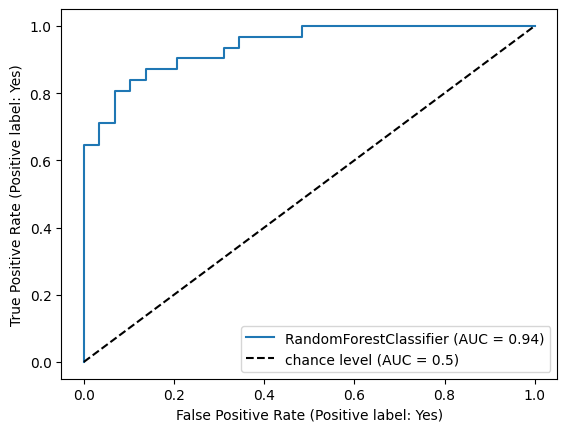

In [23]:
RocCurveDisplay.from_estimator(rfc, X_test, y_test, pos_label="Yes")
plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")
plt.legend()
plt.show()

Use `roc_curve` if you want to get the values from the plot (e.g. for threshold selection). See the documentation.

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1], pos_label="Yes")
#fpr
#tpr
#thresholds

The area under the ROC curve (AUC) is also a popular assessment metric: 

In [25]:
roc_auc_score(y_test, y_prob[:, 1])

0.9399332591768632

One can also have a look at the `yellowbrick` package for more pre-coded diagnostic plots (with `pip install yellowbrick` (https://www.scikit-yb.org/en/latest/)).

## 3. Theoretical Exercise: Properties of Bootstrap

We will now derive the probability that a given observation is part
of a bootstrap sample. 

Let $Z = \{Z_1, \dots, Z_n\}$ be our original sample of size $n$. (For example, $Z_i = (X_i, Y_i)$
can represent the pair of predictors and target variables for each observation $i = 1, \dots, n$.)

Let $Z^* = \{Z_1^*, \dots, Z_n^*\}$ be a bootstrap sample of size $n$, resampled from $Z$. (You can think of it as one of the $B$ bootstrap samples $Z^{*1},\ldots,Z^{*B}$ used for bagging.)

We want to show that, for each $i = 1, \dots, n$, the probability that $Z_i$ is part of the bootstrap sample is $P\left(Z_i \in Z^*\right) = 1 - 1/e$.

* What is the probability that the first bootstrap observation
is not the $i$-th observation from the original sample? 
Justify your answer.

* What is the probability that the second bootstrap observation
is not the $i$-th observation from the original sample?

* Argue that the probability that the $i$-th observation is not in the
bootstrap sample is $(1 - \frac{1}{n})^n$.

* When $n = 5$, what is the probability that the $i$-th observation is
in the bootstrap sample?

* When $n = 100$, what is the probability that the $i$-th observation
is in the bootstrap sample?

* When $n \to \infty$, what is the probability that the $i$-th observation
is in the bootstrap sample?

### Solution
See the appended pdf on Moodle.